# 08 — Train Improved xG Models

Train and evaluate three improved logistic-regression xG models — skill-aware,
form-aware, and combined — using the fair comparison datasets assembled in notebook 07.

All three models use the identical `StandardScaler → LogisticRegression` pipeline from
notebook 04 so that any improvement over the baseline is attributable to the new features
alone. Models are fit on the four-league train split and evaluated on held-out EPL shots.

| Model | Features | Train input |
|-------|----------|-------------|
| skill_aware | baseline + 5 skill cols | wyscout_train_xg_skill_aware.parquet |
| form_aware  | baseline + 8 form cols  | wyscout_train_xg_form_aware.parquet |
| combined    | baseline + 5 skill + 8 form | wyscout_train_xg_combined.parquet |

In [ ]:
import sys
print(sys.executable)

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from IPython.display import display

from src.config import (
    DATA_DIR, MODELS_DIR, BASELINE_FEATURES, SKILL_COLS, FORM_COLS,
    TARGET_COL, RANDOM_SEED,
)
from src.models import (
    build_logistic_xg_pipeline, train_logistic_xg, predict_xg,
    save_model, load_model,
)
from src.evaluation import metric_summary, build_calibration_table, extract_model_coefficients

## Step 0: Path validation

In [ ]:
SKILL_AWARE_TRAIN = DATA_DIR / "wyscout_train_xg_skill_aware.parquet"
SKILL_AWARE_TEST  = DATA_DIR / "wyscout_test_xg_skill_aware.parquet"
FORM_AWARE_TRAIN  = DATA_DIR / "wyscout_train_xg_form_aware.parquet"
FORM_AWARE_TEST   = DATA_DIR / "wyscout_test_xg_form_aware.parquet"
COMBINED_TRAIN    = DATA_DIR / "wyscout_train_xg_combined.parquet"
COMBINED_TEST     = DATA_DIR / "wyscout_test_xg_combined.parquet"

for path in [
    SKILL_AWARE_TRAIN, SKILL_AWARE_TEST,
    FORM_AWARE_TRAIN,  FORM_AWARE_TEST,
    COMBINED_TRAIN,    COMBINED_TEST,
]:
    assert path.exists(), f"Missing input file: {path} — run 07_build_enhanced_datasets.ipynb first"

# MODELS_DIR.mkdir() not needed — save_model() calls ensure_dir internally
print("Paths OK")

## Step 1: Constants and model registry

In [ ]:
ID_COLS = ["league", "matchId", "playerId", "teamId", "eventSec", "matchPeriod"]
TARGET  = TARGET_COL  # local alias preserves downstream cell references

# Model registry — one entry per improved model.
# xg_pred is carried as an audit column in every input dataset; it is NOT used as an
# input feature here (that would leak the baseline model's output into the new models).
MODELS = [
    {
        "name":       "skill_aware",
        "pred_col":   "xg_pred_skill_aware",
        "features":   BASELINE_FEATURES + SKILL_COLS,
        "train_path": SKILL_AWARE_TRAIN,
        "test_path":  SKILL_AWARE_TEST,
        "artifact":   MODELS_DIR / "wyscout_xg_skill_aware_logreg.joblib",
    },
    {
        "name":       "form_aware",
        "pred_col":   "xg_pred_form_aware",
        "features":   BASELINE_FEATURES + FORM_COLS,
        "train_path": FORM_AWARE_TRAIN,
        "test_path":  FORM_AWARE_TEST,
        "artifact":   MODELS_DIR / "wyscout_xg_form_aware_logreg.joblib",
    },
    {
        "name":       "combined",
        "pred_col":   "xg_pred_combined",
        "features":   BASELINE_FEATURES + SKILL_COLS + FORM_COLS,
        "train_path": COMBINED_TRAIN,
        "test_path":  COMBINED_TEST,
        "artifact":   MODELS_DIR / "wyscout_xg_combined_logreg.joblib",
    },
]
print("Constants OK")

## Step 2: Load datasets and verify cross-model alignment

All three train datasets were built from the same baseline, so `is_goal` and `xg_pred`
must be identical across them (same for test). Sorting by ID_COLS makes the comparison
order-independent.

In [6]:
skill_aware_train = pd.read_parquet(SKILL_AWARE_TRAIN)
skill_aware_test  = pd.read_parquet(SKILL_AWARE_TEST)
form_aware_train  = pd.read_parquet(FORM_AWARE_TRAIN)
form_aware_test   = pd.read_parquet(FORM_AWARE_TEST)
combined_train    = pd.read_parquet(COMBINED_TRAIN)
combined_test     = pd.read_parquet(COMBINED_TEST)

DATASETS = {
    "skill_aware_train": skill_aware_train,
    "skill_aware_test":  skill_aware_test,
    "form_aware_train":  form_aware_train,
    "form_aware_test":   form_aware_test,
    "combined_train":    combined_train,
    "combined_test":     combined_test,
}

for name, df in DATASETS.items():
    assert len(df) > 0,               f"{name} is empty"
    assert "xg_pred" in df.columns,   f"xg_pred missing from {name}"
    assert "is_goal" in df.columns,   f"is_goal missing from {name}"

TRAIN_LEAGUES = {"France", "Germany", "Italy", "Spain"}
TEST_LEAGUES  = {"England"}
for name, df in [("skill_aware_train", skill_aware_train), ("form_aware_train", form_aware_train), ("combined_train", combined_train)]:
    assert set(df["league"].unique()) == TRAIN_LEAGUES, f"Wrong train leagues in {name}"
for name, df in [("skill_aware_test", skill_aware_test), ("form_aware_test", form_aware_test), ("combined_test", combined_test)]:
    assert set(df["league"].unique()) == TEST_LEAGUES,  f"Wrong test league in {name}"

def check_col_match(df_a, df_b, col, name_a, name_b):
    a = df_a.set_index(ID_COLS)[col].sort_index()
    b = df_b.set_index(ID_COLS)[col].sort_index()
    assert a.equals(b), f"{col} differs between {name_a} and {name_b}"

for col in ["is_goal", "xg_pred"]:
    check_col_match(skill_aware_train, form_aware_train, col, "skill_aware_train", "form_aware_train")
    check_col_match(skill_aware_train, combined_train,   col, "skill_aware_train", "combined_train")
    check_col_match(skill_aware_test,  form_aware_test,  col, "skill_aware_test",  "form_aware_test")
    check_col_match(skill_aware_test,  combined_test,    col, "skill_aware_test",  "combined_test")

print("Alignment checks passed")
for name, df in DATASETS.items():
    print(f"  {name}: {df.shape}")

Alignment checks passed
  skill_aware_train: (34159, 41)
  skill_aware_test: (8881, 41)
  form_aware_train: (34159, 44)
  form_aware_test: (8881, 44)
  combined_train: (34159, 49)
  combined_test: (8881, 49)


## Step 3: Train improved models

Pipeline is identical to notebook 04 (`StandardScaler → LogisticRegression`) so that
any improvement is attributable to new features alone, not to a different model family
or hyper-parameters.

The pipeline step name `"logreg"` matches notebook 04 for consistency.

In [ ]:
pred_train_dfs    = {}
pred_test_dfs     = {}
trained_pipelines = {}

for model_cfg in MODELS:
    model_name = model_cfg["name"]
    pred_col   = model_cfg["pred_col"]
    features   = model_cfg["features"]

    train_df = pd.read_parquet(model_cfg["train_path"])
    test_df  = pd.read_parquet(model_cfg["test_path"])

    print(f"\n=== {model_name} ===")
    print(f"  features: {len(features)}  train: {len(train_df):,}  test: {len(test_df):,}")

    # Null checks — train before fit, test before predict
    assert train_df[features].notna().all().all(), f"Null in train features for {model_name}"
    assert test_df[features].notna().all().all(),  f"Null in test features for {model_name}"

    X_train = train_df[features]
    y_train = train_df[TARGET]
    X_test  = test_df[features]
    y_test  = test_df[TARGET]

    pipeline = build_logistic_xg_pipeline(random_state=RANDOM_SEED)
    pipeline = train_logistic_xg(pipeline, X_train, y_train)
    trained_pipelines[model_name] = pipeline

    # Explicit copy before appending predictions — never mutate the source DataFrames
    pred_train_df = train_df.copy()
    pred_train_df[pred_col] = predict_xg(pipeline, X_train)

    pred_test_df = test_df.copy()
    pred_test_df[pred_col] = predict_xg(pipeline, X_test)

    # Assert baseline xg_pred was not overwritten
    assert pred_train_df["xg_pred"].equals(train_df["xg_pred"]), \
        f"baseline xg_pred overwritten in {model_name} train"
    assert pred_test_df["xg_pred"].equals(test_df["xg_pred"]), \
        f"baseline xg_pred overwritten in {model_name} test"

    pred_train_dfs[model_name] = pred_train_df
    pred_test_dfs[model_name]  = pred_test_df

    coef_df = extract_model_coefficients(pipeline, features)
    print(f"\n--- {model_name} coefficients ---")
    display(coef_df)

print("\nAll models trained")

## Step 4: Compute evaluation metrics

In [ ]:
# Inline metric_summary definition removed — use src.evaluation.metric_summary.
# model_name is prepended to the dict to preserve the original column order in metrics_df.
metrics_rows = []
for model_cfg in MODELS:
    model_name = model_cfg["name"]
    pred_col   = model_cfg["pred_col"]
    train_df   = pred_train_dfs[model_name]
    test_df    = pred_test_dfs[model_name]

    for split_name, df in [("train", train_df), ("test", test_df)]:
        row = {"model_name": model_name, **metric_summary(df[TARGET], df[pred_col], split_name)}
        metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)

## Step 5: Build test comparison table

Merge the three sets of test predictions onto a single table keyed by `ID_COLS`.
Explicit column selection prevents the extra feature columns in each prediction parquet
from fan-fanning out into the merged result.

In [9]:
pred_test_skill_aware = pred_test_dfs["skill_aware"]
pred_test_form_aware  = pred_test_dfs["form_aware"]
pred_test_combined    = pred_test_dfs["combined"]

test_comparison_df = (
    pred_test_skill_aware[ID_COLS + ["is_goal", "xg_pred", "xg_pred_skill_aware"]]
    .merge(
        pred_test_form_aware[ID_COLS + ["xg_pred_form_aware"]],
        on=ID_COLS, how="left", validate="one_to_one",
    )
    .merge(
        pred_test_combined[ID_COLS + ["xg_pred_combined"]],
        on=ID_COLS, how="left", validate="one_to_one",
    )
)

assert (
    len(test_comparison_df)
    == len(pred_test_skill_aware)
    == len(pred_test_form_aware)
    == len(pred_test_combined)
), "Row count mismatch in test_comparison_df merge"

print(f"test_comparison_df: {test_comparison_df.shape}")
display(test_comparison_df.head())

test_comparison_df: (8881, 11)


,league,matchId,playerId,teamId,eventSec,matchPeriod,is_goal,xg_pred,xg_pred_skill_aware,xg_pred_form_aware,xg_pred_combined
0,England,2499719,25413,1609,94.595788,1H,1,0.137206,0.122826,0.114252,0.122490
1,England,2499719,26150,1631,179.854785,1H,0,0.117335,0.104749,0.096514,0.103708
2,England,2499719,14763,1631,254.745027,1H,1,0.421288,0.392990,0.379242,0.397953
3,England,2499719,7868,1609,425.824035,1H,0,0.044315,0.039946,0.036255,0.039344
4,England,2499719,7868,1609,815.462015,1H,0,0.020479,0.018898,0.017068,0.015508


## Step 6: Train-vs-test generalisation gap

A large gap between train and test `log_loss` indicates overfitting. For logistic
regression with L2 regularisation this should be small.

In [10]:
test_m  = metrics_df[metrics_df["split"] == "test"].set_index("model_name")
train_m = metrics_df[metrics_df["split"] == "train"].set_index("model_name")
assert set(train_m.index) == set(test_m.index), "model_name mismatch between train/test metrics"

gap_df = test_m[["log_loss", "roc_auc"]].rename(columns=lambda c: f"test_{c}")
gap_df["train_log_loss"] = train_m["log_loss"]
gap_df["train_roc_auc"]  = train_m["roc_auc"]
gap_df["gap_log_loss"]   = gap_df["test_log_loss"] - gap_df["train_log_loss"]
gap_df["gap_roc_auc"]    = gap_df["test_roc_auc"]  - gap_df["train_roc_auc"]

display(gap_df.sort_values("test_log_loss"))

,test_log_loss,test_roc_auc,train_log_loss,train_roc_auc,gap_log_loss,gap_roc_auc
model_name,,,,,,
combined,0.289753,0.788651,0.284098,0.794122,0.005656,-0.005471
skill_aware,0.289943,0.787940,0.284409,0.793702,0.005534,-0.005762
form_aware,0.290057,0.787639,0.284361,0.793463,0.005696,-0.005824


## Step 7: EPL calibration analysis

One calibration curve per model on held-out EPL shots, followed by tabular decile
summaries. Good calibration means the predicted xG closely tracks the observed goal rate
in each bin.

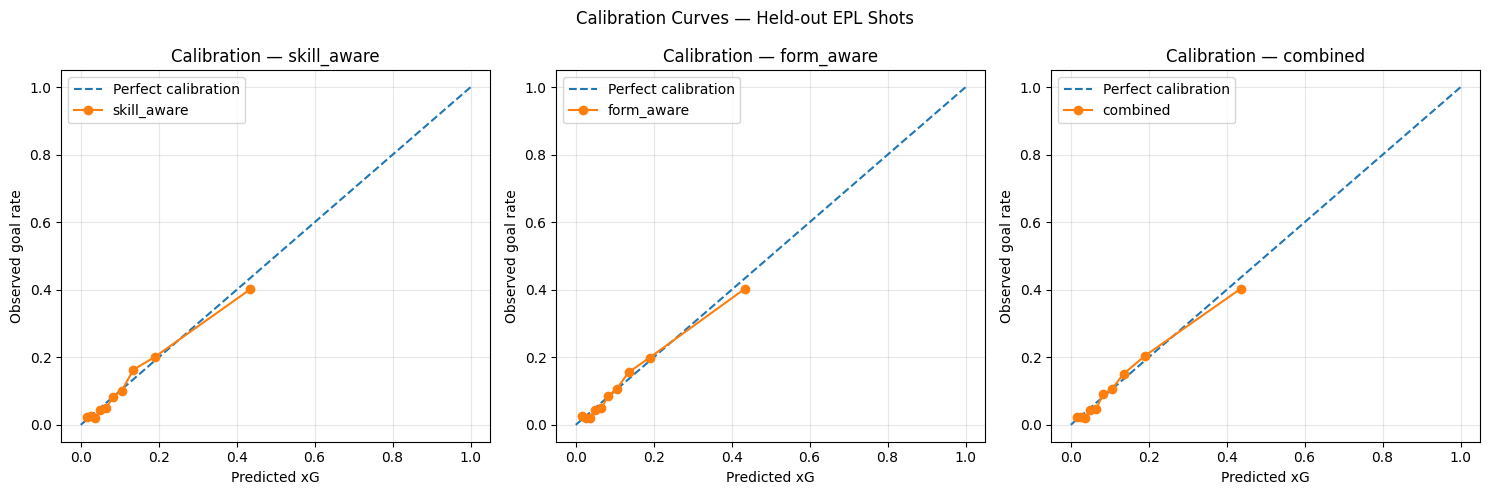

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, model_cfg in zip(axes, MODELS):
    model_name = model_cfg["name"]
    pred_col   = model_cfg["pred_col"]
    test_df    = pred_test_dfs[model_name]

    prob_true, prob_pred = calibration_curve(
        test_df[TARGET], test_df[pred_col], n_bins=10, strategy="quantile"
    )
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax.plot(prob_pred, prob_true, marker="o", label=model_name)
    ax.set_xlabel("Predicted xG")
    ax.set_ylabel("Observed goal rate")
    ax.set_title(f"Calibration — {model_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Calibration Curves — Held-out EPL Shots")
plt.tight_layout()
plt.show()

In [ ]:
for model_cfg in MODELS:
    model_name = model_cfg["name"]
    pred_col   = model_cfg["pred_col"]
    test_df    = pred_test_dfs[model_name]

    cal_table = build_calibration_table(test_df[TARGET], test_df[pred_col], n_bins=10)
    print(f"\n--- {model_name} calibration table ---")
    display(cal_table)

## Step 8: Save predictions, metrics, and model artifacts

In [13]:
for model_cfg in MODELS:
    model_name = model_cfg["name"]
    train_df   = pred_train_dfs[model_name]
    test_df    = pred_test_dfs[model_name]

    train_path = DATA_DIR / f"wyscout_train_xg_{model_name}_predictions.parquet"
    test_path  = DATA_DIR / f"wyscout_test_xg_{model_name}_predictions.parquet"

    train_df.to_parquet(train_path, index=False)
    test_df.to_parquet(test_path,   index=False)
    print(f"Saved {model_name}: {len(train_df):,} train rows, {len(test_df):,} test rows")

Saved skill_aware: 34,159 train rows, 8,881 test rows
Saved form_aware: 34,159 train rows, 8,881 test rows
Saved combined: 34,159 train rows, 8,881 test rows


In [14]:
# metrics_df.to_dict(orient="records") converts pandas values to native Python types,
# so json.dump works without a custom encoder.
with open(DATA_DIR / "wyscout_xg_improved_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_df.to_dict(orient="records"), f, indent=2)

metrics_df.to_csv(DATA_DIR / "wyscout_xg_improved_metrics.csv", index=False)
print("Saved metrics (JSON + CSV)")

Saved metrics (JSON + CSV)


In [ ]:
for model_cfg in MODELS:
    save_model(trained_pipelines[model_cfg["name"]], model_cfg["artifact"])
    print(f"Saved artifact: {model_cfg['artifact']}")

## Step 9: Reload verification

Verify all six prediction parquets and three model artifacts round-trip correctly.
The artifact check re-runs `predict_proba` on a small batch and asserts numerical
agreement with the in-memory predictions.

In [ ]:
print("Reload verification:")
for model_cfg in MODELS:
    model_name = model_cfg["name"]
    pred_col   = model_cfg["pred_col"]
    features   = model_cfg["features"]

    train_check = pd.read_parquet(DATA_DIR / f"wyscout_train_xg_{model_name}_predictions.parquet")
    test_check  = pd.read_parquet(DATA_DIR / f"wyscout_test_xg_{model_name}_predictions.parquet")

    assert pred_col in train_check.columns, f"Missing {pred_col} in saved train ({model_name})"
    assert pred_col in test_check.columns,  f"Missing {pred_col} in saved test ({model_name})"
    assert train_check[pred_col].notna().all(),        f"Null {pred_col} in train ({model_name})"
    assert test_check[pred_col].notna().all(),         f"Null {pred_col} in test ({model_name})"
    assert train_check[pred_col].between(0, 1).all(), f"{pred_col} out of [0,1] in train ({model_name})"
    assert test_check[pred_col].between(0, 1).all(),  f"{pred_col} out of [0,1] in test ({model_name})"

    # Artifact: reload and verify predictions are numerically identical to in-memory predictions
    loaded_pipeline = load_model(model_cfg["artifact"])
    test_df         = pred_test_dfs[model_name]
    loaded_preds    = predict_xg(loaded_pipeline, test_df[features])
    assert np.allclose(loaded_preds, test_df[pred_col].values, rtol=1e-5, atol=1e-9), \
        f"Reloaded model predictions differ for {model_name}"

    print(f"  {model_name}: OK ({len(train_check):,} train, {len(test_check):,} test)")

# Metrics file checks
metrics_check = pd.read_csv(DATA_DIR / "wyscout_xg_improved_metrics.csv")
assert {"model_name", "split", "roc_auc", "log_loss", "brier_score"}.issubset(metrics_check.columns)
assert set(metrics_check["split"]) == {"train", "test"}
assert set(metrics_check["model_name"]) == {"skill_aware", "form_aware", "combined"}

print("\nReload verification passed")